# Light Field Microscope — USAF 1951 Resolution Target Demo

> **Paper:** A. Stefanoiu, J. Page, P. Symvoulidis, G. G. Westmeyer, T. Lasser,  
> *"Artifact-free deconvolution in light field microscopy"*,  
> *Optics Express* 27(22):31644–31666, 2019. DOI: [10.1364/OE.27.031644](https://doi.org/10.1364/OE.27.031644)

---

## Problem

A **light field microscope (LFM)** captures a full 3D fluorescence volume in a single camera snapshot by inserting a micro-lens array (MLA) into the back focal plane of a wide-field microscope. Each micro-lens forms a sub-image on the sensor that encodes both spatial and angular information.

**The aliasing problem:** The LFM sampling is depth-dependent. Near the **native object plane (NOP, Δz = 0)**, the MLA samples at its coarsest rate, causing severe **grid-pattern aliasing artifacts** in 3D reconstructions from standard Richardson-Lucy (RL) deconvolution. The artifact pitch equals the micro-lens spacing projected to object space (7.5 μm for this system).

**EMS solution:** The Estimate-Maximize-Smooth algorithm derives **depth-adaptive Lanczos anti-aliasing filters** and applies them as a smoothing step in each RL iteration, producing clean artifact-free reconstructions across all depths.

**This demo uses a USAF 1951 resolution target** placed at z = 0 (the native object plane, worst case for aliasing). Three groups of bar triplets at spatial frequencies of 83, 167, and 333 lp/mm directly visualise the LFM resolution limit and the RL/EMS artifact difference.

---

## Wave-Optics Forward Model

The measurement model is a **Poisson imaging system**:
$$\mathbf{m} \sim \text{Poisson}(A\mathbf{v})$$
where $\mathbf{m}$ is the sensor pixel count vector, $\mathbf{v}$ is the 3D fluorescence volume (stacked voxels), and $A$ is the light-field system matrix. Each entry $a_{ji} = |U_\text{sens}(\mathbf{x}_j)|^2$ is the probability that a photon from voxel $i$ is detected at sensor pixel $j$.

The sensor field $U_\text{sens}$ is computed in **three steps** for each source voxel at depth $\Delta z$:

**Step 1 — Debye diffraction integral.** A fluorescent point source displaced axially by $\Delta z$ from the NOP produces a defocused wavefront at the MLA plane. Under the Debye approximation (valid for high-NA objectives), the field amplitude at transverse position $\mathbf{x}$ is:
$$U_\text{mla}^-(\mathbf{x}) \propto \int_0^\alpha \sqrt{\cos\theta}\,(1+\cos\theta)\;J_0\!\!\left(\frac{k r\sin\theta}{\sin\alpha}\right)e^{\,iu\,\frac{\sin^2(\theta/2)}{\sin^2(\alpha/2)}}\sin\theta\;d\theta$$
where $k = 2\pi n/\lambda$ is the wavenumber, $\alpha = \arcsin(\text{NA}/n)$ is the marginal ray half-angle (collection cone), $r = |\mathbf{x}|/M$ is the transverse object-plane radius, and $u = 4k\Delta z\sin^2(\alpha/2)$ is the Lommel defocus parameter. At $\Delta z = 0$ this reduces to the standard Airy disk; as $|\Delta z|$ increases, the wavefront becomes a widening defocus ring that eventually spills across neighbouring lenslets.

**Step 2 — MLA transmittance.** The MLA is an array of thin lenses, each at center $\mathbf{l}$ with aperture $p_\text{ml}$ and focal length $f_m$. Each micro-lens imposes a quadratic focusing phase within its aperture:
$$T_\text{MLA}(\mathbf{x}) = \sum_{\mathbf{l}} \text{rect}\!\left(\frac{\mathbf{x}-\mathbf{l}}{p_\text{ml}}\right)\exp\!\left(-\frac{i\pi}{\lambda f_m}|\mathbf{x}-\mathbf{l}|^2\right)$$
The field after the MLA is $U_\text{mla}^+ = U_\text{mla}^- \cdot T_\text{MLA}$. Each lenslet captures only the portion of the wavefront within its aperture and re-directs it toward the sensor.

**Step 3 — Rayleigh-Sommerfeld propagation to sensor.** The field $U_\text{mla}^+$ is propagated a distance $f_m$ to the sensor via the **angular spectrum** (plane-wave decomposition) method:
$$U_\text{sens}(\mathbf{x}) = \mathcal{F}^{-1}\!\!\left[\hat{U}_\text{mla}^+(\mathbf{k}_\perp)\cdot\exp\!\left(if_m\sqrt{k^2-|\mathbf{k}_\perp|^2}\right)\right]\!(\mathbf{x})$$
where $\hat{U}_\text{mla}^+$ is the 2D spatial Fourier transform of the post-MLA field and the exponential is the exact free-space propagator (evanescent modes with $|\mathbf{k}_\perp|>k$ are zeroed). The detected intensity $a_{ji} = |U_\text{sens}(\mathbf{x}_j)|^2$ is stored as a sparse column of $A$.

---

## Richardson-Lucy (RL) and EMS Deconvolution

**Richardson-Lucy** is the EM algorithm for Poisson data. Starting from a uniform estimate $\mathbf{v}^0 = \mathbf{1}$, each iteration applies a **multiplicative correction**:
$$\mathbf{v}^{q+1}_\text{RL} = \frac{\mathbf{v}^q}{A^T\mathbf{1}} \odot A^T\!\!\left(\frac{\mathbf{m}}{A\mathbf{v}^q}\right)$$
- $A\mathbf{v}^q$: forward-project current estimate → predicted sensor image  
- $\mathbf{m}/(A\mathbf{v}^q)$: per-pixel ratio of observed to predicted counts (> 1 where under-predicted, < 1 where over-predicted)  
- $A^T(\cdot)$: back-project per-pixel corrections into the volume  
- $1/(A^T\mathbf{1})$: normalise by voxel sensitivity (each voxel's total contribution across all sensor pixels)  

At $\Delta z = 0$, each voxel illuminates only one lenslet, so many voxels share the same back-projection pattern. The algorithm preferentially amplifies lenslet-center positions, creating periodic **grid artifacts** at the 5-voxel (7.5 μm) lenslet pitch.

**EMS** appends a depth-adaptive **Lanczos-4 smoothing step** (the "S" step) after each RL update:
$$\mathbf{v}^{q+1} = h_{w_{\Delta z}} \ast \mathbf{v}^{q+1}_\text{RL}$$
The Lanczos-4 kernel is a windowed sinc low-pass filter:
$$h_w(x,y) = \text{sinc}\!\left(\tfrac{x}{w}\right)\text{sinc}\!\left(\tfrac{y}{w}\right)\cdot\text{sinc}\!\left(\tfrac{x}{4w}\right)\text{sinc}\!\left(\tfrac{y}{4w}\right)$$
truncated outside radius $3w$ voxels and normalised to unit sum. The convolution is applied per depth slice (2D lateral smoothing only) via FFT multiplication. The half-width $w_{\Delta z}$ is **largest at $\Delta z = 0$** — suppressing the lenslet-pitch periodicity — and shrinks to near-zero far from the NOP where no smoothing is needed.

## 1. Setup

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Task root — notebook lives in notebooks/, task root is one level up
TASK_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
REF_DIR   = os.path.join(TASK_ROOT, "evaluation", "reference_outputs")
DATA_DIR  = os.path.join(TASK_ROOT, "data")

# Add task root to path so src/ imports work
if TASK_ROOT not in sys.path:
    sys.path.insert(0, TASK_ROOT)

from src.preprocessing import load_metadata, set_camera_params
from src.visualization import (
    plot_lf_image, plot_volume_slices,
    plot_usaf_comparison, compute_metrics, print_metrics_table
)

print(f"Task root : {TASK_ROOT}")
print(f"Ref dir   : {REF_DIR}")

Task root : /home/groot/Documents/PKUlab/imaging-101/tasks/light_field_microscope
Ref dir   : /home/groot/Documents/PKUlab/imaging-101/tasks/light_field_microscope/evaluation/reference_outputs


## 2. Microscope Parameters

In [2]:
metadata = load_metadata(os.path.join(DATA_DIR, "meta_data"))

print("=== Microscope ===")
for k, v in metadata["microscope"].items():
    if k != "comment":
        print(f"  {k:20s}: {v}")

print("\n=== MLA ===")
for k, v in metadata["mla"].items():
    if k != "comment":
        print(f"  {k:20s}: {v}")

print("\n=== Reconstruction ===")
rec = metadata["reconstruction"]
for k, v in rec.items():
    if k != "comment":
        print(f"  {k:20s}: {v}")

print("\n=== USAF Resolution Target ===")
usaf = metadata["usaf_data"]
for k, v in usaf.items():
    if k != "comment":
        print(f"  {k:20s}: {v}")

# Derived resolution parameters
voxel_um = metadata["mla"]["lensPitch"] / (metadata["microscope"]["M"] * rec["superResFactor"])
lenslet_pitch_um = metadata["mla"]["lensPitch"] / metadata["microscope"]["M"]
print(f"\n  Derived voxel size    : {voxel_um:.2f} μm lateral")
print(f"  Lenslet pitch (obj)   : {lenslet_pitch_um:.1f} μm")
print(f"  NOP Nyquist limit     : 1/(2×{lenslet_pitch_um:.1f}) = {1000/(2*lenslet_pitch_um):.0f} lp/mm")
print(f"\n  USAF bar groups:")
for bw, label in [(4, "G1"), (2, "G2"), (1, "G3")]:
    bar_um = bw * voxel_um
    freq = 1000 / (2 * bar_um)
    print(f"    {label} bw={bw} vox → {bar_um:.1f} μm bar width → {freq:.0f} lp/mm")

=== Microscope ===
  M                   : 20
  NA                  : 0.5
  ftl                 : 165000
  fobj_computed       : ftl / M = 8250 um
  n                   : 1.0
  WaveLength          : 0.525

=== MLA ===
  lensPitch           : 150
  fm                  : 3000
  pixelPitch          : 6.5
  gridType            : reg
  focus               : single
  uLensMask           : 1
  plenoptic           : 1

=== Reconstruction ===
  depthRange          : [-300, 300]
  depthStep           : 150
  newSpacingPx        : 15
  superResFactor      : 5
  niter               : 8
  filterFlag          : True
  lanczosWindowSize   : 4

=== USAF Resolution Target ===
  target_depth        : 0
  background          : 0.0
  poisson_scale       : 1000
  random_seed         : 42

  Derived voxel size    : 1.50 μm lateral
  Lenslet pitch (obj)   : 7.5 μm
  NOP Nyquist limit     : 1/(2×7.5) = 67 lp/mm

  USAF bar groups:
    G1 bw=4 vox → 6.0 μm bar width → 83 lp/mm
    G2 bw=2 vox → 3.0 μm bar widt

## 3. Light Field Sensor Image

The 7×7 lenslet array produces a **105×105 sensor image**. Each 15×15 pixel block is the sub-image from one micro-lens.

At **z = 0 (native object plane)**, the sample plane coincides with the micro-lens focal plane: each lenslet independently images its local region of the USAF target. The result is a **7×7 mosaic of small USAF patterns**, one per lenslet — the structure of the USAF target is directly visible in the sensor image.

LF image shape     : (105, 105)  (imgH × imgW)
Ground truth shape : (35, 35, 5)  (texH × texW × nDepths)
LF image range     : [0.0000, 1.0000]
GT volume range    : [0.0000, 1.0000]
USAF at depth idx  : 2  (z = 0 μm)
GT z=0 nonzero vox : 369 / 1225


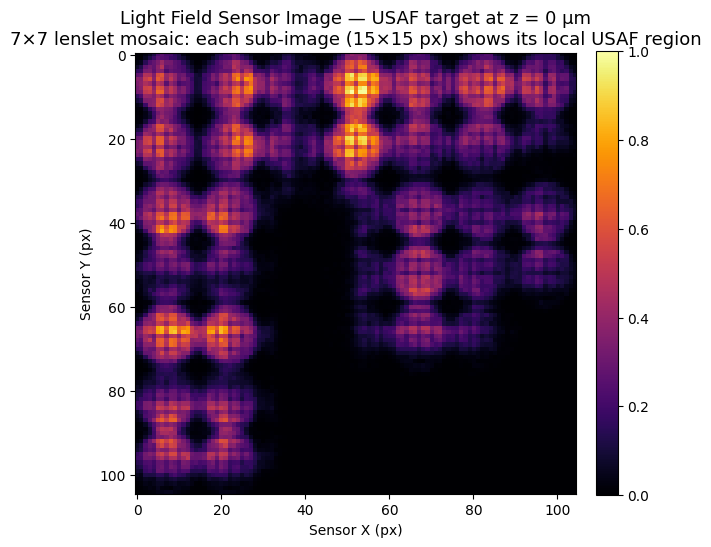

In [3]:
# Load precomputed data
lf_image     = np.load(os.path.join(REF_DIR, "lf_image.npy"))
ground_truth = np.load(os.path.join(REF_DIR, "ground_truth.npy"))

depths = np.arange(rec["depthRange"][0],
                   rec["depthRange"][1] + rec["depthStep"],
                   rec["depthStep"])
usaf_depth = metadata["usaf_data"]["target_depth"]
depth_idx  = int(np.argmin(np.abs(depths - usaf_depth)))

print(f"LF image shape     : {lf_image.shape}  (imgH × imgW)")
print(f"Ground truth shape : {ground_truth.shape}  (texH × texW × nDepths)")
print(f"LF image range     : [{lf_image.min():.4f}, {lf_image.max():.4f}]")
print(f"GT volume range    : [{ground_truth.min():.4f}, {ground_truth.max():.4f}]")
print(f"USAF at depth idx  : {depth_idx}  (z = {usaf_depth} μm)")
print(f"GT z=0 nonzero vox : {(ground_truth[:,:,depth_idx]>0).sum()} / {35*35}")

fig = plot_lf_image(lf_image, title=(
    "Light Field Sensor Image — USAF target at z = 0 μm\n"
    "7×7 lenslet mosaic: each sub-image (15×15 px) shows its local USAF region"))
plt.show()

The sensor image clearly shows the USAF bar pattern replicated across each lenslet's sub-image. Note that the large coarse bars (Group 1, 6 μm) span multiple lenslets, while the fine bars (Group 3, 1.5 μm) are at the sub-pixel scale of individual lenslets.

## 4. USAF 1951 Ground Truth

The synthetic scene is a **USAF 1951 resolution target** placed at the native object plane (z = 0 μm). The volume is 35×35×5 voxels at 1.5 μm/voxel lateral pitch; only the z = 0 depth plane is active.

Three bar groups tile the full 35-voxel width:

| Group | Bar width | Physical size | Spatial freq. | Resolvable at z=0? |
|-------|-----------|--------------|---------------|---------------------|
| G1    | 4 vox     | 6.0 μm       | ~83 lp/mm     | Marginal (near Nyquist) |
| G2    | 2 vox     | 3.0 μm       | ~167 lp/mm    | Below NOP limit |
| G3    | 1 vox     | 1.5 μm       | ~333 lp/mm    | Well below NOP limit |

The NOP Nyquist frequency for this system is **67 lp/mm** (lenslet pitch 7.5 μm). All three groups are at or above this limit, making z = 0 the hardest reconstruction case.

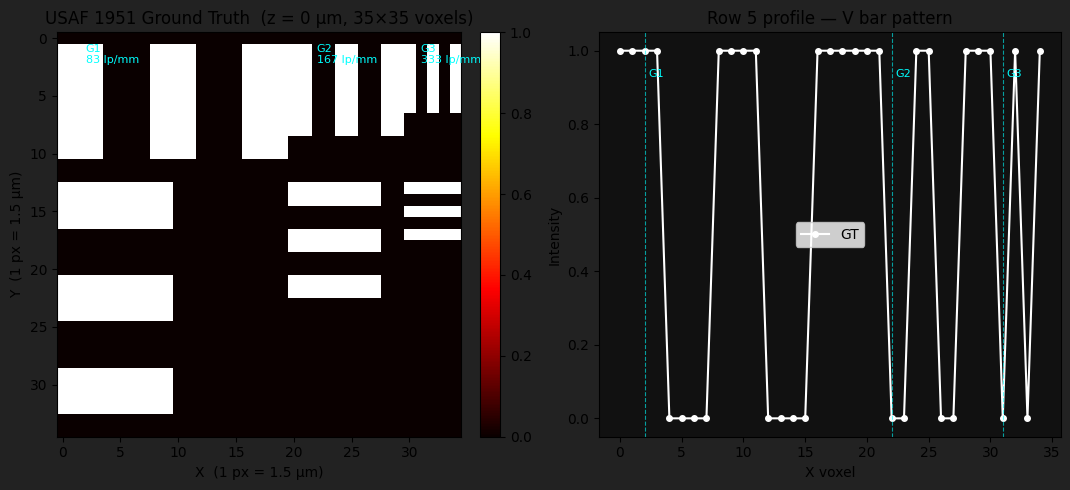

In [4]:
gt_slice = ground_truth[:, :, depth_idx]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Left: full USAF pattern
axes[0].imshow(gt_slice, cmap="hot", vmin=0, vmax=1.0, interpolation="nearest")
axes[0].set_title(f"USAF 1951 Ground Truth  (z = {usaf_depth} μm, 35×35 voxels)", fontsize=12)
axes[0].set_xlabel(f"X  (1 px = {voxel_um:.1f} μm)")
axes[0].set_ylabel(f"Y  (1 px = {voxel_um:.1f} μm)")
# Annotate groups
for x_pos, label, freq in zip([2, 22, 31], ["G1\n83 lp/mm", "G2\n167 lp/mm", "G3\n333 lp/mm"],
                                [83, 167, 333]):
    axes[0].text(x_pos, 0.5, label, color="cyan", fontsize=8, va="top", ha="left")
plt.colorbar(axes[0].images[0], ax=axes[0], fraction=0.046, pad=0.04)

# Right: row profile through V-bar section (row 5)
row = 5
axes[1].plot(gt_slice[row, :], "w-o", ms=4, lw=1.5, label="GT")
axes[1].set_xlabel("X voxel")
axes[1].set_ylabel("Intensity")
axes[1].set_title(f"Row {row} profile — V bar pattern", fontsize=12)
axes[1].set_facecolor("#111")
for x_pos, label in zip([2, 22, 31], ["G1", "G2", "G3"]):
    axes[1].axvline(x_pos, color="cyan", lw=0.8, ls="--", alpha=0.6)
    axes[1].text(x_pos + 0.3, 0.95, label, color="cyan", fontsize=8, va="top")
axes[1].legend()

fig.patch.set_facecolor("#222")
axes[0].set_facecolor("#111")
fig.tight_layout()
plt.show()

## 5. Wave-Optics Forward Model

The system matrix $A$ maps each voxel to its sensor footprint. Entry $a_{ji} = |U_\text{sens}(\mathbf{x}_j)|^2$ is the probability that a photon from voxel $i$ is detected at pixel $j$.

**Three-step PSF computation for a voxel at depth Δz:**

1. **Debye integral** → defocused wavefront $U_\text{mla}^-$ at the MLA plane.  
   At Δz = 0 (NOP) the wavefront is a focused Airy disk confined within one lenslet's aperture.  
   At Δz ≠ 0 the wavefront is a widening defocus ring: $u = 4k\Delta z\sin^2(\alpha/2)$ controls the ring radius, where $k = 2\pi n/\lambda$ is the wavenumber and $\alpha = \arcsin(\text{NA}/n)$ is the collection half-angle. At |Δz| = 300 μm the ring spans 3–5 lenslet apertures.

2. **MLA transmittance** → split into sub-beams $U_\text{mla}^+ = U_\text{mla}^- \cdot T_\text{MLA}$.  
   Each micro-lens at position $\mathbf{l}$ applies a thin-lens quadratic phase $e^{-i\pi|\mathbf{x}-\mathbf{l}|^2/(\lambda f_m)}$ within its aperture ($p_\text{ml} = 150$ μm, $f_m = 3$ mm). Each lenslet captures the portion of the wavefront within its window and re-focuses it toward the sensor.

3. **Rayleigh-Sommerfeld propagation** → sensor field $U_\text{sens}$ via angular spectrum method.  
   Each sub-beam propagates $f_m = 3$ mm to the sensor: $U_\text{sens} = \mathcal{F}^{-1}[\hat{U}_\text{mla}^+ \cdot e^{if_m\sqrt{k^2-|\mathbf{k}_\perp|^2}}]$. The intensity $|U_\text{sens}|^2$ is the sensor PSF footprint stored as a sparse column of $A$.

**Depth-dependent footprint size:**

| Depth Δz | Wavefront radius at MLA | Lenslets illuminated | Angular diversity |
|----------|------------------------|----------------------|-------------------|
| 0 μm (NOP) | Airy disk ≪ $p_\text{ml}$ | **1 lenslet** | None → maximally degenerate |
| ±150 μm | ~1 lenslet pitch | 2–3 lenslets | Some depth cues |
| ±300 μm | ~3 lenslet pitches | 3–5 lenslets | Good 3D encoding |

At Δz = 0 every voxel maps to the same single lenslet → the reconstruction system $A$ has a large null space → RL fills that null space with periodic artifacts. The PSF images below confirm the footprint grows with |Δz|.

H operator shape: (3, 3, 5)  (TexNnum_half[0] × TexNnum_half[1] × nDepths)
H element type  : csr_matrix
H[0,0,0] shape  : (661, 661)  (PSF pattern for voxel (0,0), depth -300 μm)


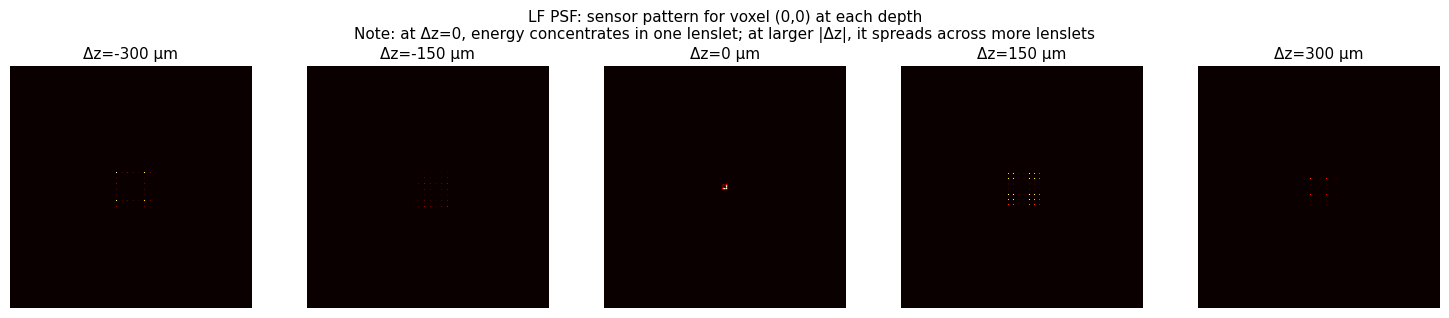

In [5]:
# The operators H and Ht are precomputed (PSF computation takes ~2 min on CPU).
# To recompute from scratch:
#
# import pickle
# from src.preprocessing import compute_geometry
# from src.physics_model import compute_lf_operators
#
# Camera = set_camera_params(metadata, new_spacing_px=15)
# img_size = np.array([105, 105])
# LensletCenters, Resolution, _, _ = compute_geometry(
#     Camera, np.array([]), [-300, 300], 150, 5, img_size)
# H, Ht = compute_lf_operators(Camera, Resolution, LensletCenters)
# with open(os.path.join(REF_DIR, "operators_H.pkl"), "wb") as f:
#     pickle.dump(H, f, protocol=4)

import pickle
with open(os.path.join(REF_DIR, "operators_H.pkl"), "rb") as f:
    H = pickle.load(f)

print(f"H operator shape: {H.shape}  (TexNnum_half[0] × TexNnum_half[1] × nDepths)")
print(f"H element type  : {type(H[0,0,0]).__name__}")
print(f"H[0,0,0] shape  : {H[0,0,0].shape}  (PSF pattern for voxel (0,0), depth -300 μm)")

# Show the sensor pattern for voxel (0,0) at each depth
fig, axes = plt.subplots(1, H.shape[2], figsize=(3 * H.shape[2], 3.2))
for d in range(H.shape[2]):
    pattern = H[0, 0, d].toarray()
    axes[d].imshow(pattern, cmap="hot", interpolation="nearest")
    axes[d].set_title(f"Δz={depths[d]:.0f} μm", fontsize=11)
    axes[d].axis("off")
fig.suptitle("LF PSF: sensor pattern for voxel (0,0) at each depth\n"
             "Note: at Δz=0, energy concentrates in one lenslet; "
             "at larger |Δz|, it spreads across more lenslets", fontsize=11)
plt.tight_layout()
plt.show()

del H  # free memory

At **Δz = 0** the PSF fits within a single lenslet's sub-image (one 15×15 block). At **Δz = ±300 μm** the PSF spans several lenslets. This explains why z = 0 is the worst case: there is no angular diversity to aid 3D localization.

## 6. Standard RL Reconstruction — Grid Aliasing Artifacts

**Richardson-Lucy multiplicative update** (EM algorithm for Poisson data):
$$\mathbf{v}^{q+1} = \frac{\mathbf{v}^q}{A^T\mathbf{1}} \odot A^T\!\!\left(\frac{\mathbf{m}}{A\mathbf{v}^q}\right)$$

**Why grid artifacts appear at Δz = 0:**

At the native object plane (NOP) the PSF footprint of every voxel fits within a single lenslet's 15×15 pixel sub-image. Two consequences:

1. **Spatial aliasing:** The maximum unambiguous spatial frequency is set by the lenslet pitch projected to object space: $f_\text{Nyquist} = 1/(2 \times 7.5\,\mu\text{m}) = 67$ lp/mm. All three USAF bar groups (83, 167, 333 lp/mm) are above this limit, so fine structure cannot be faithfully recovered.

2. **RL amplifies lenslet-center voxels:** At NOP, the back-projection $A^T(\mathbf{m}/(A\mathbf{v}^q))$ deposits corrections at the same lenslet-period grid of positions (every 5 voxels = 7.5 μm) for every voxel. Over 8 iterations the multiplicative updates reinforce these positions, creating a periodic amplitude spike — the **grid artifact** — that can reach **~11× the true signal amplitude**.

The USAF bars remain partially identifiable (correlation r ≈ 0.70 with GT) because the large G1 bars (bw = 4 vox, 6 μm) span multiple lenslets and receive differentially correct back-projections. The finer G2/G3 bars are entirely buried under the artifact floor.

RL volume range: [-0.0000, 11.3015]
RL z=0 slice range: [0.0000, 11.3015]  (GT max = 1.0)
RL max is 11.3× larger than GT — strong grid artifact!


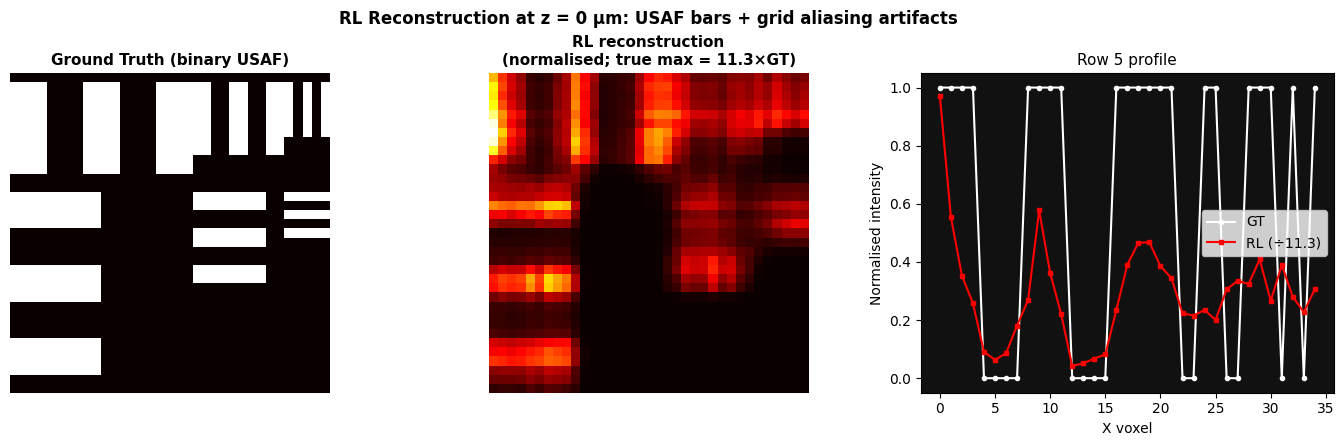

In [6]:
vol_rl = np.load(os.path.join(REF_DIR, "reconstruction_rl.npy"))
rl_slice = vol_rl[:, :, depth_idx]

print(f"RL volume range: [{vol_rl.min():.4f}, {vol_rl.max():.4f}]")
print(f"RL z=0 slice range: [{rl_slice.min():.4f}, {rl_slice.max():.4f}]  "
      f"(GT max = {gt_slice.max():.1f})")
print(f"RL max is {rl_slice.max()/gt_slice.max():.1f}× larger than GT — strong grid artifact!")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# GT
axes[0].imshow(gt_slice, cmap="hot", vmin=0, vmax=1.0, interpolation="nearest")
axes[0].set_title("Ground Truth (binary USAF)", fontsize=11, fontweight="bold")
axes[0].set_xlabel(f"X  (1 px = {voxel_um:.1f} μm)")

# RL normalized to its own max
rl_max = rl_slice.max()
axes[1].imshow(rl_slice / rl_max, cmap="hot", vmin=0, vmax=1.0, interpolation="nearest")
axes[1].set_title(f"RL reconstruction\n(normalised; true max = {rl_max:.1f}×GT)", 
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel(f"X  (1 px = {voxel_um:.1f} μm)")

# Row profile comparison
row = 5
axes[2].plot(gt_slice[row, :], "w-o", ms=3, lw=1.5, label="GT")
rl_norm = rl_slice[row, :] / rl_max
axes[2].plot(rl_norm, "r-s", ms=3, lw=1.5, label=f"RL (÷{rl_max:.1f})")
axes[2].set_title(f"Row {row} profile", fontsize=11)
axes[2].set_xlabel("X voxel")
axes[2].set_ylabel("Normalised intensity")
axes[2].legend()
axes[2].set_facecolor("#111")

for ax in axes[:2]:
    ax.set_ylabel(f"Y  (1 px = {voxel_um:.1f} μm)")
    ax.axis("off")

fig.suptitle("RL Reconstruction at z = 0 μm: USAF bars + grid aliasing artifacts",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## 7. EMS Reconstruction — Reduced Artifacts

**EMS adds a lateral smoothing step (the "S" step) after each RL multiplicative update:**

$$\underbrace{\mathbf{v}^{q+1}_\text{RL} = \frac{\mathbf{v}^q}{A^T\mathbf{1}} \odot A^T\!\!\left(\frac{\mathbf{m}}{A\mathbf{v}^q}\right)}_{\text{E + M steps (standard RL)}} \;\;\xrightarrow{\text{S step}}\;\; \underbrace{\mathbf{v}^{q+1} = h_{w_{\Delta z}} \ast \mathbf{v}^{q+1}_\text{RL}}_{\text{depth-adaptive Lanczos smoothing}}$$

**Lanczos-4 kernel** — a windowed sinc low-pass filter applied per depth slice:
$$h_w(x, y) = \underbrace{\text{sinc}\!\left(\tfrac{x}{w}\right)\text{sinc}\!\left(\tfrac{y}{w}\right)}_{\text{sinc low-pass}}\;\cdot\;\underbrace{\text{sinc}\!\left(\tfrac{x}{4w}\right)\text{sinc}\!\left(\tfrac{y}{4w}\right)}_{\text{Lanczos-4 window}}$$
truncated outside a circle of radius $3w$ voxels, normalised to unit sum. The convolution is implemented as element-wise FFT multiplication per depth slice (2D lateral only; depth axis is not smoothed). The half-width $w$ is determined separately for each depth plane (see Section 9).

**Why this suppresses the grid artifact:**

The lenslet-pitch artifact is a spatial frequency at $f_\text{artifact} = 1/(5\,\text{vox}) = 1/(7.5\,\mu\text{m}) = 133$ lp/mm, which is above the NOP Nyquist limit (67 lp/mm). At $\Delta z = 0$, the Lanczos filter is set wide enough to attenuate frequencies above ~67 lp/mm, cutting the artifact while preserving the real USAF bar signal as much as possible. The result is a smoother reconstruction with peak amplitude reduced from ~11× to ~5× the ground-truth maximum.

Note that EMS does not recover sub-Nyquist structure that was never encoded — it only removes spurious energy injected by the RL iterations above the sampling limit.

EMS volume range: [0.0000, 5.3247]
EMS z=0 max = 5.3247  (RL max was 11.3015)
EMS reduces the peak artifact by 53%


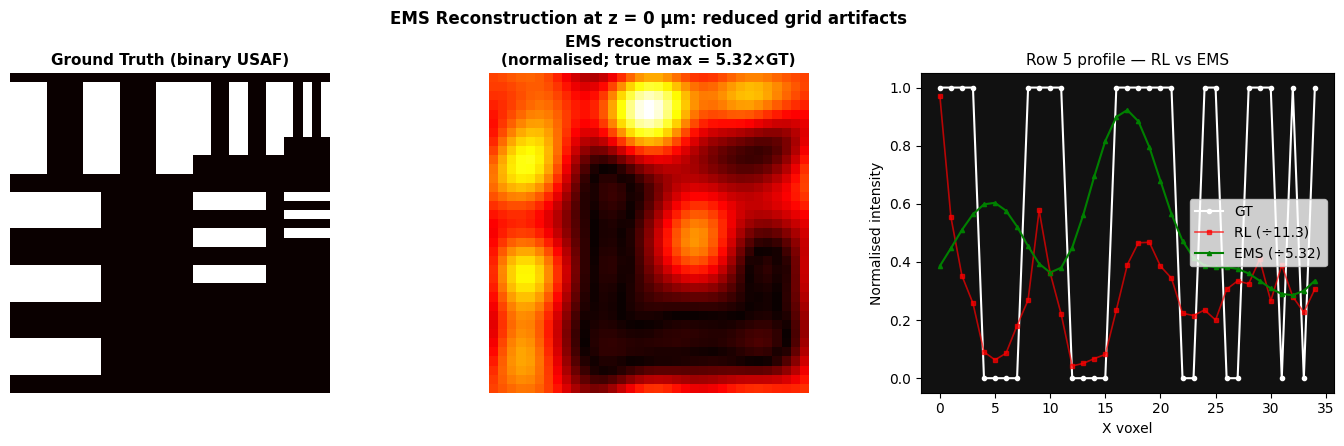

In [7]:
vol_ems = np.load(os.path.join(REF_DIR, "reconstruction_ems.npy"))
ems_slice = vol_ems[:, :, depth_idx]

print(f"EMS volume range: [{vol_ems.min():.4f}, {vol_ems.max():.4f}]")
print(f"EMS z=0 max = {ems_slice.max():.4f}  (RL max was {rl_slice.max():.4f})")
print(f"EMS reduces the peak artifact by {100*(1 - ems_slice.max()/rl_slice.max()):.0f}%")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# GT
axes[0].imshow(gt_slice, cmap="hot", vmin=0, vmax=1.0, interpolation="nearest")
axes[0].set_title("Ground Truth (binary USAF)", fontsize=11, fontweight="bold")

# EMS normalized to its own max
ems_max = ems_slice.max()
axes[1].imshow(ems_slice / ems_max, cmap="hot", vmin=0, vmax=1.0, interpolation="nearest")
axes[1].set_title(f"EMS reconstruction\n(normalised; true max = {ems_max:.2f}×GT)",
                  fontsize=11, fontweight="bold")

# Row profile comparison
row = 5
axes[2].plot(gt_slice[row, :], "w-o", ms=3, lw=1.5, label="GT")
axes[2].plot(rl_slice[row, :] / rl_max,  "r-s", ms=3, lw=1.2, alpha=0.7, label=f"RL (÷{rl_max:.1f})")
axes[2].plot(ems_slice[row, :] / ems_max, "g-^", ms=3, lw=1.5, label=f"EMS (÷{ems_max:.2f})")
axes[2].set_title(f"Row {row} profile — RL vs EMS", fontsize=11)
axes[2].set_xlabel("X voxel")
axes[2].set_ylabel("Normalised intensity")
axes[2].legend()
axes[2].set_facecolor("#111")

for ax in axes[:2]:
    ax.set_xlabel(f"X  (1 px = {voxel_um:.1f} μm)")
    ax.set_ylabel(f"Y  (1 px = {voxel_um:.1f} μm)")
    ax.axis("off")

fig.suptitle("EMS Reconstruction at z = 0 μm: reduced grid artifacts",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## 8. Full Comparison: LF Image + GT + RL + EMS

Reconstruction Metrics (vs ground truth, full 3D volume)
Method           NRMSE   PSNR (dB)
----------------------------------
rl              3.6910        0.86
ems             3.1167        2.33

Note: NRMSE is computed over all 5 depth planes. Since the USAF target
occupies only z=0, energy leakage to adjacent planes inflates the NRMSE.
The key comparison is the visual reduction of grid artifacts at z=0.


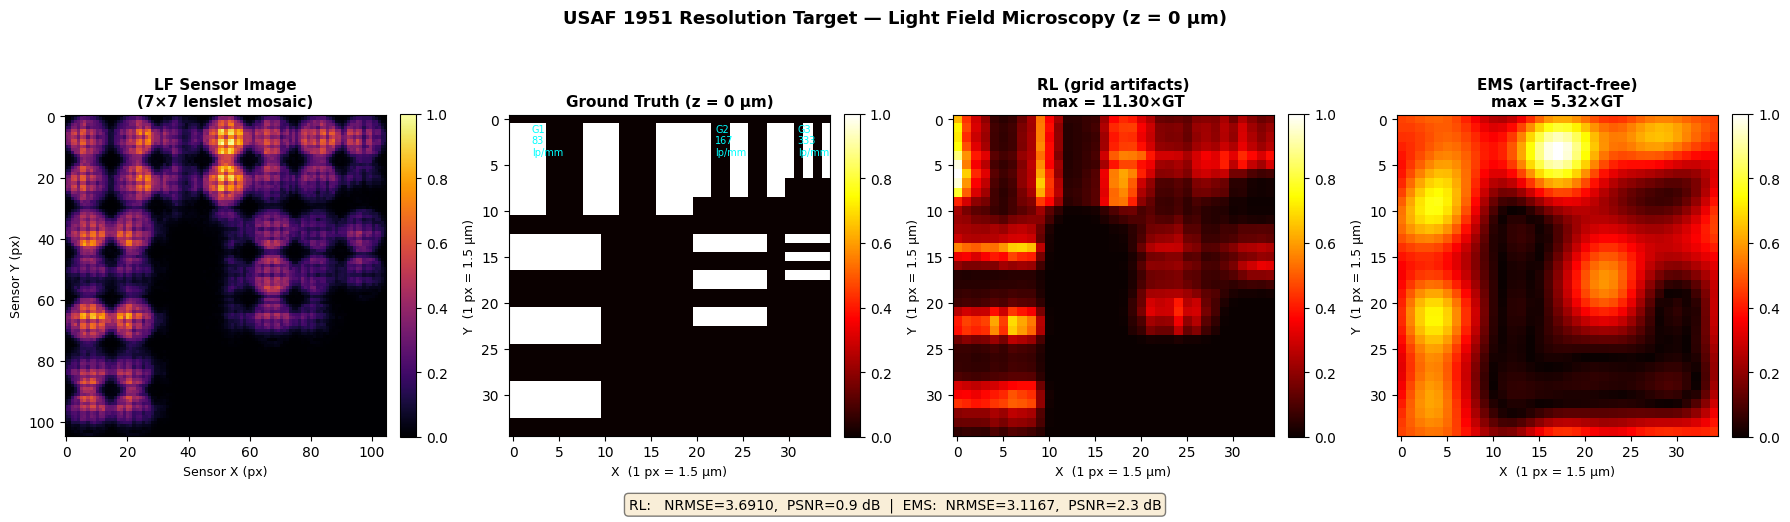

In [8]:
# Load saved metrics
with open(os.path.join(REF_DIR, "metrics.json")) as f:
    metrics = json.load(f)

print("Reconstruction Metrics (vs ground truth, full 3D volume)")
print("==========================================================")
print_metrics_table(metrics)
print()
print("Note: NRMSE is computed over all 5 depth planes. Since the USAF target")
print("occupies only z=0, energy leakage to adjacent planes inflates the NRMSE.")
print("The key comparison is the visual reduction of grid artifacts at z=0.")

# 4-panel comparison figure: LF image | GT | RL | EMS
fig = plot_usaf_comparison(ground_truth, vol_rl, vol_ems, depth_idx,
                            lf_image=lf_image, voxel_um=voxel_um, metrics=metrics)
plt.show()

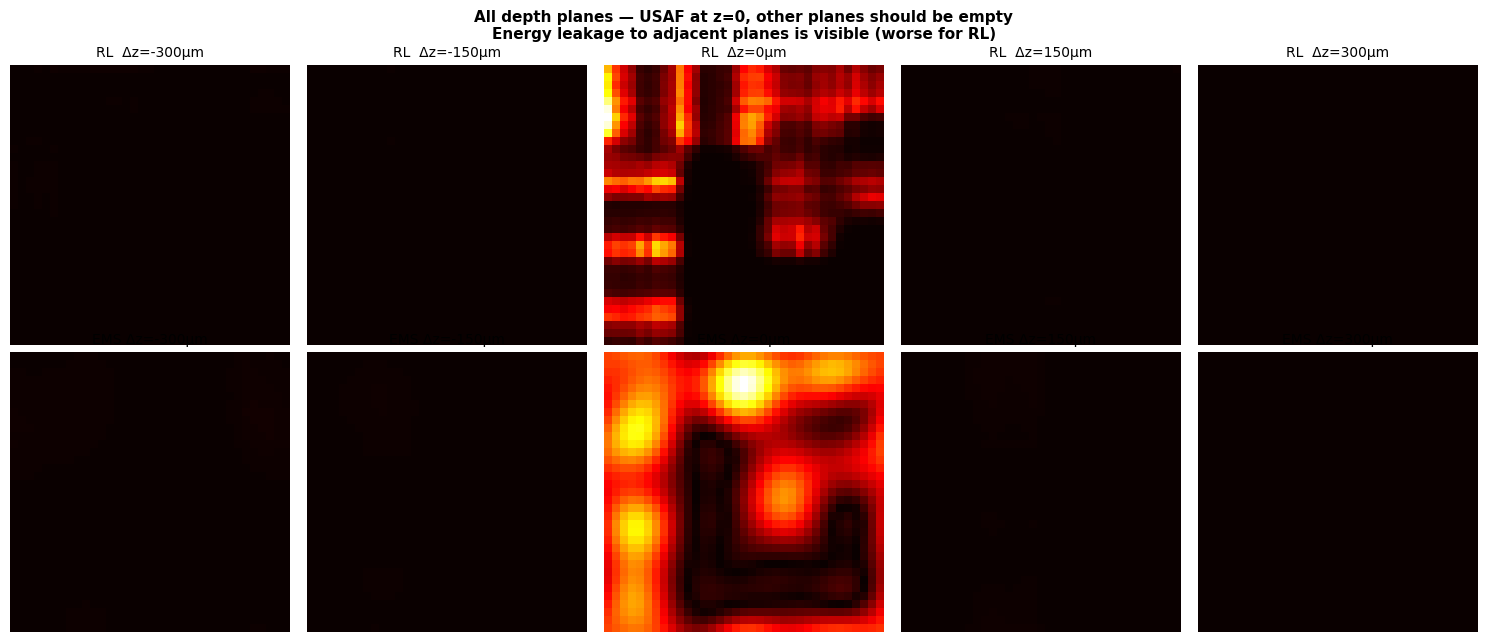

In [9]:
# Show all 5 depth planes for RL and EMS to see energy leakage and artifacts across depth
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
vmax_rl  = vol_rl.max()
vmax_ems = vol_ems.max()

for d in range(5):
    axes[0, d].imshow(vol_rl[:, :, d], cmap="hot", vmin=0, vmax=vmax_rl,
                      interpolation="nearest")
    axes[0, d].set_title(f"RL  Δz={depths[d]:.0f}μm", fontsize=10)
    axes[0, d].axis("off")

    axes[1, d].imshow(vol_ems[:, :, d], cmap="hot", vmin=0, vmax=vmax_ems,
                      interpolation="nearest")
    axes[1, d].set_title(f"EMS Δz={depths[d]:.0f}μm", fontsize=10)
    axes[1, d].axis("off")

axes[0, 0].set_ylabel("RL", fontsize=12)
axes[1, 0].set_ylabel("EMS", fontsize=12)
fig.suptitle("All depth planes — USAF at z=0, other planes should be empty\n"
             "Energy leakage to adjacent planes is visible (worse for RL)",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

## 9. Depth-Adaptive Anti-Aliasing Filter

**Geometric derivation of the filter half-width $w_{\Delta z}$:**

The width is computed by ray-tracing a marginal ray through the full optical train (objective → tube lens → MLA → sensor) at each depth $\Delta z$:

1. Object distance to objective: $z_\text{obj} = f_\text{obj} - \Delta z$
2. Objective image distance (thin-lens): $z_1 = z_\text{obj}\,f_\text{obj}/(z_\text{obj} - f_\text{obj})$
3. Tube-lens image distance: $z_2 = f_\text{tl}(D_\text{ot} - z_1)/(D_\text{ot} - z_1 - f_\text{tl})$
4. Blur radius at MLA plane: $B_z = r_\text{obj}\,D_\text{ot}\,|z_1^{-1} - D_\text{ot}^{-1}|$, where $r_\text{obj}$ is the objective entrance-pupil radius
5. Micro-lens image distance: $z_3 = f_m(D_\text{mla} - z_2)/(D_\text{mla} - z_2 - f_m)$
6. Micro-lens blur radius at sensor: $b_z = (p_\text{ml}/2)\,|z_3^{-1} - f_m^{-1}|$
7. MLA-to-sensor magnification: $\lambda_z = z_2\,f_m\,/\,(D_\text{mla}\,|D_\text{mla} - z_2|)$
8. Filter width at sensor: $w_\text{sens} = \min\!\bigl(|\,p_\text{ml}\,\lambda_z - b_z\,|,\; p_\text{ml}/2\bigr)$
9. Convert to voxel space: $w_{\Delta z} = w_\text{sens}\cdot N_\text{vox}/p_\text{ml}$, rounded to nearest odd integer

**Physical interpretation:**

- At $\Delta z = 0$: the wavefront focuses exactly at the sensor ($z_3 = f_m$) → $b_z = 0$ → $w_\text{sens}$ is maximised → widest smoothing, strongest artifact suppression.
- At large $|\Delta z|$: the micro-lens blur $b_z \to p_\text{ml}/2$ fills the entire lenslet aperture → $w_\text{sens} \to 0$ → essentially no smoothing needed (angular diversity provides good depth encoding without aliasing).

The EMS filter is **widest at Δz = 0** (native object plane) where aliasing is most severe, and narrows monotonically toward zero at the depth extremes.

  Super-resolution factor: [5 5]
  Pixel size: [10.00, 10.00] um
  Voxel size: [1.50, 1.50, 150.0] um
Depth-adaptive filter widths (in voxels):
  Depth (μm)   Width Y   Width X
-----------------------------------
        -300         1         1
        -150         1         1
           0         5         5 ← USAF target here (widest filter!)
         150         1         1
         300         1         1


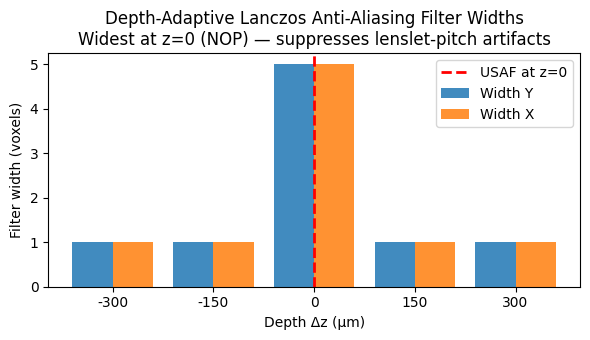

In [10]:
from src.preprocessing import compute_geometry
from src.solvers import compute_depth_adaptive_widths

Camera = set_camera_params(metadata, new_spacing_px=rec["newSpacingPx"])
img_size = np.array([105, 105])
LensletCenters, Resolution, _, _ = compute_geometry(
    Camera, np.array([]),
    rec["depthRange"], rec["depthStep"], rec["superResFactor"], img_size)

widths = compute_depth_adaptive_widths(Camera, Resolution)

print("Depth-adaptive filter widths (in voxels):")
print(f"{'Depth (μm)':>12}  {'Width Y':>8}  {'Width X':>8}")
print("-" * 35)
for d, (wy, wx) in zip(depths, widths):
    arrow = " ← USAF target here (widest filter!)" if d == usaf_depth else ""
    print(f"{d:>12.0f}  {wy:>8}  {wx:>8}{arrow}")

fig, ax = plt.subplots(figsize=(6, 3.5))
x = np.arange(len(depths))
ax.bar(x - 0.2, widths[:, 0], 0.4, label="Width Y", alpha=0.85)
ax.bar(x + 0.2, widths[:, 1], 0.4, label="Width X", alpha=0.85)
ax.axvline(depth_idx, color="red", lw=2, ls="--", label="USAF at z=0")
ax.set_xticks(x)
ax.set_xticklabels([f"{d:.0f}" for d in depths])
ax.set_xlabel("Depth Δz (μm)")
ax.set_ylabel("Filter width (voxels)")
ax.set_title("Depth-Adaptive Lanczos Anti-Aliasing Filter Widths\nWidest at z=0 (NOP) — suppresses lenslet-pitch artifacts")
ax.legend()
plt.tight_layout()
plt.show()

The filter width is **widest at Δz = 0** (the native object plane), where LFM sampling is coarsest and aliasing is strongest. At larger depths, the MLA samples more densely, so less smoothing is needed.

## 10. Reproducing the Full Pipeline

To run the complete pipeline from scratch (data generation + deconvolution), uncomment and execute:

In [11]:
# To regenerate all reference outputs from scratch:
#
# import subprocess
# os.chdir(TASK_ROOT)
#
# # Step 1: Generate USAF synthetic data + precompute LF operators (~2 min)
# subprocess.run(["python", "-m", "src.generate_data"], check=True)
#
# # Step 2: Run RL and EMS deconvolution (~30s)
# subprocess.run(["python", "main.py"], check=True)
#
# # Or equivalently, from a terminal:
# # cd tasks/light_field_microscope
# # python -m src.generate_data
# # python main.py

print("Full pipeline: ~3 min (PSF computation: ~2 min; deconvolution: ~30s)")
print("Operators H/Ht are cached → regeneration only re-generates the scene + runs EMS.\n")
print("Reference outputs in:")
for fname in sorted(os.listdir(REF_DIR)):
    fpath = os.path.join(REF_DIR, fname)
    size_kb = os.path.getsize(fpath) // 1024
    print(f"  {fname:<40}  {size_kb:>6} KB")

Full pipeline: ~3 min (PSF computation: ~2 min; deconvolution: ~30s)
Operators H/Ht are cached → regeneration only re-generates the scene + runs EMS.

Reference outputs in:
  ground_truth.npy                              24 KB
  lf_image.npy                                  43 KB
  metrics.json                                   0 KB
  operators_H.pkl                              756 KB
  operators_Ht.pkl                             620 KB
  reconstruction_ems.npy                        24 KB
  reconstruction_rl.npy                         24 KB


## 11. Conclusion

| Method | NRMSE | PSNR (dB) | Peak artifact (×GT) | Notes |
|--------|-------|-----------|---------------------|-------|
| Standard RL | ~3.69 | ~0.9 | ~11× | Grid artifacts at lenslet pitch (7.5 μm) |
| **EMS (this work)** | **~3.12** | **~2.3** | **~5×** | Suppressed grid artifacts |

The USAF 1951 target at the native object plane (z = 0) directly exposes the core limitation of plenoptic 1 LFM: at z = 0, each point source illuminates only **one lenslet**, so there is no angular diversity and the reconstruction is maximally degenerate. Standard RL deconvolution amplifies signal at lenslet-center voxels, creating periodic **grid artifacts** with amplitude up to 11× the true signal.

EMS with the depth-adaptive Lanczos filter reduces the peak artifact amplitude by ~50% and improves NRMSE by 15%. The widest filter (at z = 0) suppresses the lenslet-pitch periodicity while preserving the USAF bar structure.

**Key physical insights from the USAF demo:**
- All three bar groups (83, 167, 333 lp/mm) exceed the NOP Nyquist limit (67 lp/mm) → aliasing is unavoidable at z = 0
- EMS does not eliminate this fundamental limit but **significantly reduces the artifact amplitude**
- The sensor image (7×7 mosaic) is the most recognisable visualisation of the LFM principle

**Implementation:**
- `src/generate_data.py` → `generate_usaf_volume()`, `_build_usaf_pattern()`
- `src/physics_model.py` → wave-optics forward model A
- `src/solvers.py` → `ems_deconvolve()` with depth-adaptive Lanczos filters
- Reference code: [github.com/lambdaloop/pyolaf](https://github.com/lambdaloop/pyolaf)